## Preprocesamiento — Conversión de labels VisDrone a formato YOLO

Los labels originales de VisDrone usan coordenadas en **píxeles absolutos**
con la esquina superior izquierda como origen. YOLO requiere coordenadas
**normalizadas** (entre 0 y 1) con el **centro** del bbox como referencia.

### Fórmula de conversión

Dado `x_izq, y_arr, w, h` en píxeles y resolución de imagen `W x H`:

| Campo | Fórmula | Explicación |
|-------|---------|-------------|
| x_centro_norm | (x_izq + w/2) / W | Esquina izquierda + mitad del ancho = centro en X; se divide entre W para normalizar |
| y_centro_norm | (y_arr + h/2) / H | Esquina superior + mitad del alto = centro en Y; se divide entre H para normalizar |
| w_norm | w / W | Ancho del bbox dividido entre el ancho de la imagen |
| h_norm | h / H | Alto del bbox dividido entre el alto de la imagen |

### ¿Qué se pierde en la conversión?

Los campos `score`, `truncation` y `occlusion` no se conservan
porque no son necesarios para el entrenamiento:
- `score` -> ya se usó para filtrar regiones ignoradas en el EDA
- `truncation` y `occlusion` -> son metadatos de evaluación del
  benchmark, no de entrenamiento

### Script de conversión

La conversión se realiza con el script ubicado en:
`src/preprocessing/convert_visdrone_to_yolo.py`

El script procesa los tres splits (train, val, test), lee la resolución
real de cada imagen y sobreescribe los labels originales con el formato
YOLO normalizado.

Antes de ejecutarlo se realizó un backup de los labels originales en:
`data/visdrone/labels_original_backup

## Verificación de la conversión

Visualizamos una imagen de muestra con los labels convertidos para
confirmar que los bboxes están correctamente posicionados sobre los objetos.

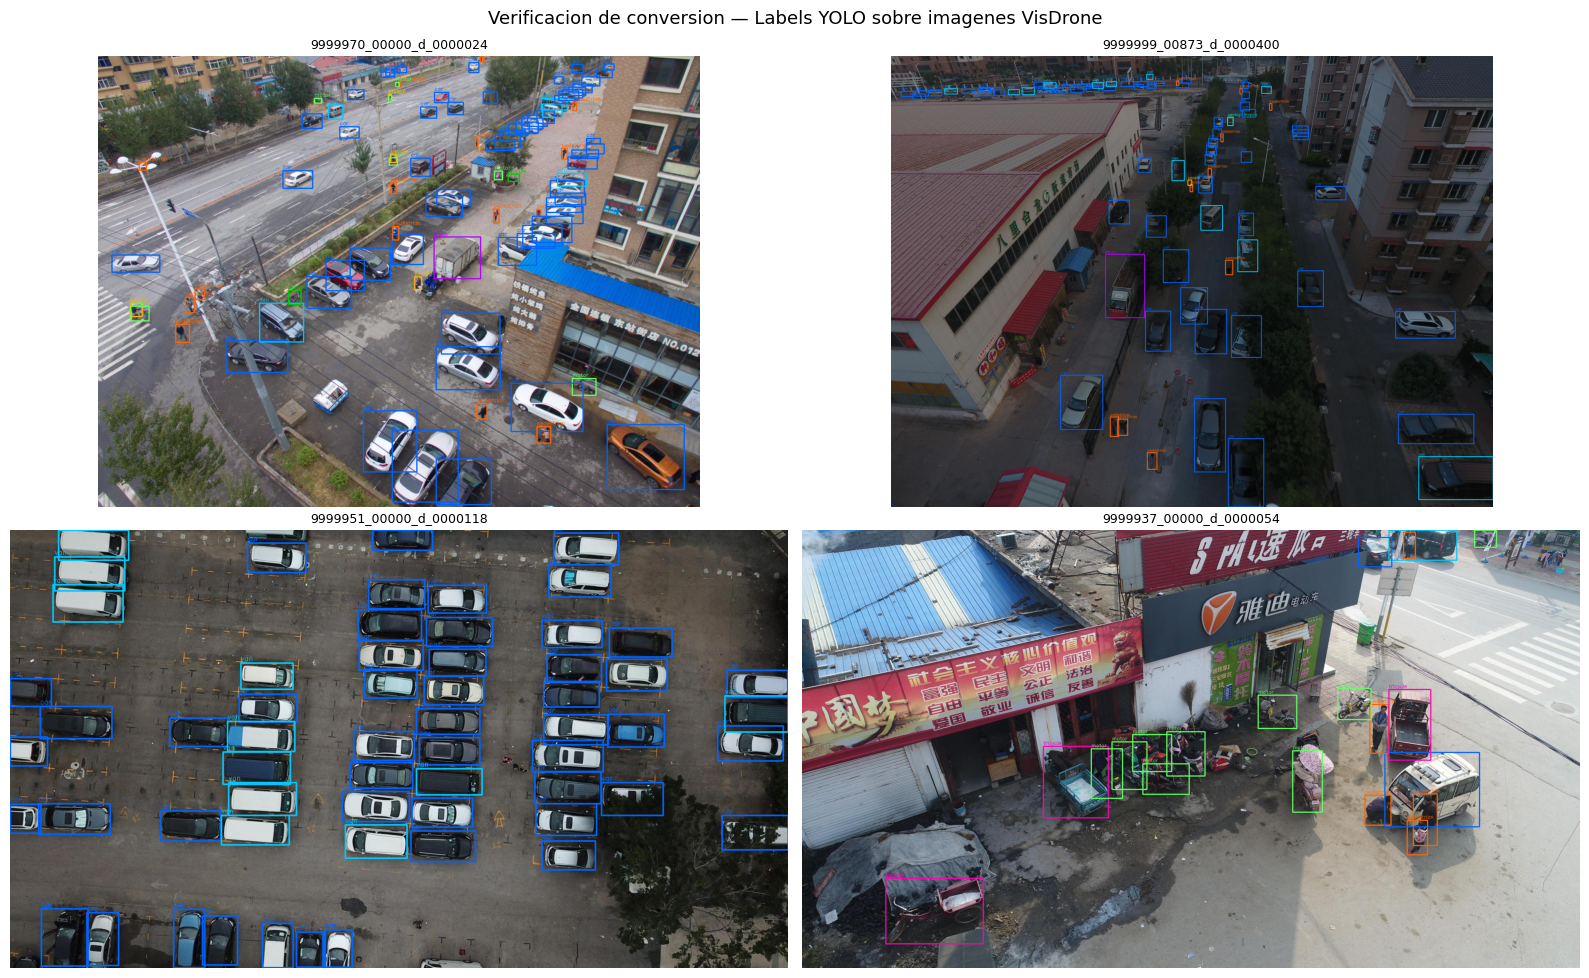

In [1]:
# Verificación visual de la conversión
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT=Path("..")
IMAGES_DIR=PROJECT_ROOT/"data"/"visdrone"/"images"/"train"
LABELS_DIR=PROJECT_ROOT/"data"/"visdrone"/"labels"/"train"

# Diccionario de clases: id → nombre
CLASS_NAMES={
    0: "pedestrian",
    1: "people",
    2: "bicycle",
    3: "car", 
    4: "van",5: "truck",
    6: "tricycle",
    7: "awning-tricycle",
    8: "bus",
    9: "motor"
}

# Diccionario de colores por clase (RGB)
CLASS_COLORS={
    0: (255,100,0),   
    1: (255,180,0),  
    2: (0,200,0),
    3: (0,100,255),   
    4: (0,200,255),  
    5: (180,0,255),
    6: (255,0,180),   
    7: (0,255,180),  
    8: (255,0,0),
    9: (100,255,100)
}

def draw_yolo_bboxes(img_name):
    # Rutas de imagen y label correspondiente
    img_path=IMAGES_DIR/f"{img_name}.jpg"
    label_path=LABELS_DIR/f"{img_name}.txt"

    # Cargar imagen y convertir de BGR a RGB
    img=cv2.imread(str(img_path))
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Obtener dimensiones para desnormalizar coordenadas
    H,W=img.shape[:2]

    with open(label_path) as f:
        for line in f:
            parts=line.strip().split()

            # Cada linea debe tener exactamente 5 valores
            if len(parts)!=5:
                continue

            # Extraer valores del formato YOLO
            cat_id,x_c,y_c,w,h=int(parts[0]),float(parts[1]),float(parts[2]),float(parts[3]),float(parts[4])

            # Convertir de coordenadas normalizadas a pixeles absolutos
            x1=int((x_c-w/2)*W)
            y1=int((y_c-h/2)*H)
            x2=int((x_c+w/2)*W)
            y2=int((y_c+h/2)*H)

            # Obtener color y nombre de la clase
            color=CLASS_COLORS.get(cat_id, (255,255,255))
            label=CLASS_NAMES.get(cat_id, str(cat_id))

            # Dibujar bbox y etiqueta sobre la imagen
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
            cv2.putText(img, label, (x1,y1-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return img

# Seleccionar 4 imagenes aleatorias del conjunto de labels
random.seed(99)
sample=random.sample([p.stem for p in LABELS_DIR.glob("*.txt")], 4)

# Crear cuadricula de 2x2 subplots
fig,axes=plt.subplots(2, 2, figsize=(16,10))

# Aplanar para acceder con un solo indice
axes=axes.flatten()

# Dibujar cada imagen con sus bboxes en su subplot
for i,img_name in enumerate(sample):
    img=draw_yolo_bboxes(img_name)
    axes[i].imshow(img)
    axes[i].set_title(img_name, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Verificacion de conversion — Labels YOLO sobre imagenes VisDrone", fontsize=13)
plt.tight_layout()

# Guardar figura en resultados
plt.savefig(PROJECT_ROOT/"results"/"figures"/"eda"/"18_verificacion_conversion.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Resultado de la verificación
Los bounding boxes convertidos se posicionan correctamente sobre
los objetos en todas las imágenes de muestra. La conversión de
formato VisDrone original a formato YOLO normalizado fue exitosa.

## Configuración de Augmentación

La augmentación de datos se configura en `configs/visdrone.yaml` y es
aplicada automáticamente por Ultralytics durante el entrenamiento.
No requiere código adicional. Los parámetros se leen del yaml al
iniciar cada epoch.

### ¿Qué es cada técnica?

- **mosaic** — combina 4 imágenes distintas en una sola escena dividida
  en cuadrantes. Fuerza al modelo a detectar objetos en contextos muy
  variados y simula escenas de alta densidad.

- **mixup** — mezcla dos imágenes con transparencia superpuesta.
  Hace al modelo más robusto ante variaciones visuales y superposición
  de objetos.

- **copy_paste** — recorta objetos de una imagen y los pega en otra.
  Especialmente útil para clases minoritarias. Aumenta artificialmente
  su representación sin recolectar datos adicionales.

- **hsv_h / hsv_s / hsv_v** — variaciones de tono, saturación y brillo
  en el espacio de color HSV. Simulan diferentes condiciones de
  iluminación (día, noche, nubes, contraluz).

- **fliplr** — voltea la imagen horizontalmente (espejo izquierda-derecha).
  Aumenta variedad de perspectivas sin alterar la semántica de los objetos.

- **flipud** — voltea la imagen verticalmente (espejo arriba-abajo).
  En perspectiva aérea se desactiva porque el cielo siempre está arriba.

- **scale** — aplica zoom aleatorio a la imagen. Simula el dron
  volando a diferentes altitudes, lo que cambia el tamaño aparente
  de los objetos.

- **translate** — desplaza la imagen aleatoriamente en X e Y.
  Simula el movimiento de la cámara entre frames consecutivos.

### Justificación de cada valor

| Técnica | Valor | Justificación basada en el EDA |
|---------|-------|-------------------------------|
| mosaic | 1.0 | Al 100% — densidad media de 53 obj/imagen exige que el modelo vea escenas densas en cada epoch sin excepción |
| mixup | 0.15 | Valor bajo — es agresivo y puede confundir al modelo si se abusa. Solo 15% para robustez general |
| copy_paste | 0.3 | Activado (default=0.0) — desbalance de 44.7x justifica copiar instancias de clases minoritarias en otras imágenes |
| hsv_h | 0.015 | Muy bajo — el tono cambia el color del objeto. Solo variación mínima para no alterar colores reales |
| hsv_s | 0.7 | Alto — simula variación entre día soleado y nublado confirmada en el EDA |
| hsv_v | 0.4 | Moderado — simula variación de brillo día/noche sin generar imágenes completamente oscuras |
| fliplr | 0.5 | 50% estándar — un coche hacia la derecha es igual de válido que uno hacia la izquierda |
| flipud | 0.0 | Desactivado — en perspectiva aérea el cielo siempre está arriba. Voltear verticalmente generaría imágenes irreales |
| scale | 0.5 | Simula el dron a diferentes altitudes con zoom ±50%, cubriendo el rango típico de VisDrone |
| translate | 0.1 | Bajo — 10% de desplazamiento para simular movimiento de cámara sin cortar objetos en los bordes |

### Nota sobre copy_paste y clases minoritarias

El EDA identificó tres clases críticas con menos de 6,000 instancias:
- `awning-tricycle` : 3,243 instancias (0.94%)
- `tricycle`        : 4,803 instancias (1.40%)
- `bus`             : 5,926 instancias (1.73%)

El copy_paste con valor 0.3 incrementa artificialmente su representación
pegando instancias de estas clases en imágenes donde no aparecen,
sin necesidad de recolectar datos adicionales.